# Initial Anomaly Detection Results
## File: anomaly_results_testbed_system_1_30s...csv

In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, auc

In [280]:
try:
    df = pd.read_csv('/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/AnomalyDetectionResults/anomaly_results_testbed_system_1_30s_2021-04-09T182330+00_2025-04-09T182300+00.csv', sep=",", encoding='utf-8', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   is_true_negative   253 non-null    int64  
 1   is_true_positive   253 non-null    int64  
 2   is_false_positive  253 non-null    int64  
 3   is_false_negative  253 non-null    int64  
 4   bucket             253 non-null    object 
 5   system_id          253 non-null    object 
 6   duration           253 non-null    int64  
 7   num_attacks        253 non-null    int64  
 8   snapshot_id        118 non-null    object 
 9   anomaly_score      118 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 19.9+ KB


The table has 253 rows and 10 columns. It describes a labeled anomaly-detection dataset, where each row records a system snapshot with confusion-matrix flags, metadata and scoring fields. snapshot_id and anomaly_score are partially populated, each having 153 missing values.

In [282]:
df.head()

,is_true_negative,is_true_positive,is_false_positive,is_false_negative,bucket,system_id,duration,num_attacks,snapshot_id,anomaly_score
0,0,1,0,0,2021-04-09 18:23:30+00:00,testbed_system_1,30,5184,testbed_system_1_30s_2021-04-09 18:23:30+00:00,0.598197
1,0,1,0,0,2021-04-09 18:24:00+00:00,testbed_system_1,30,2328,testbed_system_1_30s_2021-04-09 18:24:00+00:00,0.595870
2,0,1,0,0,2021-04-09 18:24:30+00:00,testbed_system_1,30,29526,testbed_system_1_30s_2021-04-09 18:24:30+00:00,0.593669
3,0,0,1,0,2021-04-09 18:25:00+00:00,testbed_system_1,30,0,testbed_system_1_30s_2021-04-09 18:25:00+00:00,0.589503
4,0,1,0,0,2021-04-09 18:25:30+00:00,testbed_system_1,30,18288792,testbed_system_1_30s_2021-04-09 18:25:30+00:00,0.584332


##Columns:
1. is_true_negative
2. is_true_positive
3. is_false_positive
4. is_false_negative
5. bucket
6. system_id
7. duration
8. num_attacks
9. snapshot_id
10. anomaly_score

<br>

## P.S.
The sample also shows exactly one of the four flags is set per row, so it's 0/1-encoded. The possibility of zero or multiple flags set for a row must be validated. There's a very large outlier in num_attacks that may skew summaries or plots. If IDs change or multiple tables are rendered, functions may target the wrong element, because the code repeatedly queries the DOM by ID strings.

In [283]:
# Validate single flag invariant
flags = ['is_true_negative','is_true_positive','is_false_positive','is_false_negative']
(df[flags].sum(axis=1) != 1).sum()

# Detect num_attacks outliers using the IQR rule
q1,q3 = df['num_attacks'].quantile([0.25,0.75]); iqr=q3-q1
df[df['num_attacks'] > q3 + 1.5*iqr]

# Count missing snapshot_id and anomaly_score
df[['snapshot_id','anomaly_score']].isna().sum()

,0
snapshot_id,135
anomaly_score,135


Recommended actions: sanitize and validate the data before rendering by enforcing the one-hot flag invariant, handling NaNs in snapshot_id/anomaly_score and flagging/removing num_attacks outliers

## Sanitizing and validating the data

In [284]:
# Variables
flags = ['is_true_negative','is_true_positive','is_false_positive','is_false_negative']

# how many rows violate the exactly-one-hot rule
violations = (df[flags].sum(axis=1) != 1)
print("Rows violating one-hot:", violations.sum())

# show samples of offending rows for inspection
df[violations].head(20)

Rows violating one-hot: 0


,is_true_negative,is_true_positive,is_false_positive,is_false_negative,bucket,system_id,duration,num_attacks,snapshot_id,anomaly_score


No rows violate the one-hot invariant, so every row has exactly one of the four confusion flags set.

In [285]:
# Create a canonical outcome column to simplify grouping, plotting and metrics
flags = ['is_true_negative','is_true_positive','is_false_positive','is_false_negative']
outcome_map = {
    'is_true_negative': 'tn',
    'is_true_positive': 'tp',
    'is_false_positive': 'fp',
    'is_false_negative': 'fn'
}

df['outcome'] = df[flags].idxmax(axis=1).map(outcome_map).astype('category')

In [286]:
# Verify outcome matches the flags
# reconstructed from flags (should equal df['outcome'])
recon = df[flags].idxmax(axis=1).map(outcome_map).astype('category')
assert (recon == df['outcome']).all()

# counts per outcome
df['outcome'].value_counts()

,count
outcome,
tn,74
fn,61
tp,60
fp,58


The data is roughly balanced across the four outcomes, but it's not a perfect balance. Offenders are tn 74, fn 61, tp 60 and fp 58. 253 rows thus have a slightly higher share of true negatives, but the other three classes have a somewhat even distribution. Good news -- many standard metrics will be meaningful without any heavy class-weight adjustments. The 61 false negatives and the 58 false positives are similar in terms of magnitude to the true positives, so detection errors are substantial enough to deserve targeted analysis.

In [287]:
# Use canonical outcome column to compute aggregate metrics
# Also compute per-system/bucket breakdowns

tp = int(df['is_true_positive'].sum())
tn = int(df['is_true_negative'].sum())
fp = int(df['is_false_positive'].sum())
fn = int(df['is_false_negative'].sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float('nan')

tp, tn, fp, fn, precision, recall, f1

(60, 74, 58, 61, 0.5084745762711864, 0.49586776859504134, 0.502092050209205)

The detection model performs close to chance for positives. About half of its predicted positives are correct, catching about half of the actual positives. False positives and false negatives are almost as common as true positives. Both of the error types affect performance.
<br>
<br>
To Do:
1. Inspect the representative FP and FN rows to find labeling/feature issues (focus on anomaly_score, num_attacks, system_id and snapshot_id)
2. Use the anomaly_score to determine a decision threshold (PR curve preferably); we should trade precision vs. recall depending on the operational cost of FP vs. FN
3. Check the per-system and per-bucket breakdowns to find systems/time buckets with worse precision/recall

In [288]:
# Manual review
# 1. Show preferred example FP/FN for manual review
print(df[df['is_false_positive']==1][['system_id','snapshot_id','num_attacks','anomaly_score']].head(10))
print(df[df['is_false_negative']==1][['system_id','snapshot_id','num_attacks','anomaly_score']].head(10))

# 2. Judging per-system performance
per_sys = df.groupby('system_id')[['is_true_positive','is_false_positive','is_false_negative','is_true_negative']].sum()
per_sys['precision'] = per_sys['is_true_positive'] / (per_sys['is_true_positive'] + per_sys['is_false_positive'])
per_sys['recall'] = per_sys['is_true_positive'] / (per_sys['is_true_positive'] + per_sys['is_false_negative'])
per_sys.sort_values('recall').head(10)

# 3. Threshold tuning with PR curve and anomaly_score
mask = df['anomaly_score'].notna()
y_true = (df['is_true_positive'] | df['is_false_negative']).astype(int)
y_score = df.loc[mask, 'anomaly_score']
prec, rec, thr = precision_recall_curve(y_true[mask], y_score)
pr_auc = auc(rec, prec)
print("PR AUC:", pr_auc)

           system_id                                     snapshot_id  \
3   testbed_system_1  testbed_system_1_30s_2021-04-09 18:25:00+00:00   
10  testbed_system_1  testbed_system_1_30s_2021-04-09 18:28:30+00:00   
11  testbed_system_1  testbed_system_1_30s_2021-04-09 18:29:00+00:00   
12  testbed_system_1  testbed_system_1_30s_2021-04-09 18:29:30+00:00   
16  testbed_system_1  testbed_system_1_30s_2021-04-09 18:31:30+00:00   
17  testbed_system_1  testbed_system_1_30s_2021-04-09 18:32:00+00:00   
18  testbed_system_1  testbed_system_1_30s_2021-04-09 18:32:30+00:00   
19  testbed_system_1  testbed_system_1_30s_2021-04-09 18:33:00+00:00   
25  testbed_system_1  testbed_system_1_30s_2021-04-09 18:36:00+00:00   
26  testbed_system_1  testbed_system_1_30s_2021-04-09 18:36:30+00:00   

    num_attacks  anomaly_score  
3             0       0.589503  
10            0       0.590437  
11            0       0.592004  
12            0       0.588308  
16            0       0.587840  
17       

The anomaly_score currently has a moderate ability to separate positive from negative cases, as evidenced by PR AUC = 0.6636. It's better than random, but far from perfect.

## Notes:
1. If FN more costly than FP, lower threshold to raise recall at cost of precision
2. If FP more costly, raise threshold to improve precision
3. If many errors in few systems, consider system-specific threshold/feature
4. If anomaly_score poorly separates outcomes (detected by low PR AUC), engineer feature or retrain

## Preprocessing and validating the input

In [289]:
print(df.describe(include="all"))

        is_true_negative  is_true_positive  is_false_positive  \
count         253.000000        253.000000         253.000000   
unique               NaN               NaN                NaN   
top                  NaN               NaN                NaN   
freq                 NaN               NaN                NaN   
mean            0.292490          0.237154           0.229249   
std             0.455808          0.426181           0.421183   
min             0.000000          0.000000           0.000000   
25%             0.000000          0.000000           0.000000   
50%             0.000000          0.000000           0.000000   
75%             1.000000          0.000000           0.000000   
max             1.000000          1.000000           1.000000   

        is_false_negative                     bucket         system_id  \
count          253.000000                        253               253   
unique                NaN                        253                 1 

Duration is notably constant at 30, and num_attacks is certainly skewed with large outliers. The flag means can be used as proxies for class prevalence, confirming outcome counts. num_attacks will distort means and visualizations, so use robust stats or transforms.

In [290]:
# Checking again to reduce influence by handling outliers, etc.
#1) Ensure flags are boolean and create canonical outcome
flags = ['is_true_negative','is_true_positive','is_false_positive','is_false_negative']
df[flags] = df[flags].astype(bool)
outcome_map = {'is_true_negative':'tn','is_true_positive':'tp','is_false_positive':'fp','is_false_negative':'fn'}
df['outcome'] = df[flags].idxmax(axis=1).map(outcome_map).astype('category')

# 2) Robust num_attacks handling -- inspect, cap and transform
print(df['num_attacks'].describe(percentiles=[.25,.5,.75,.9,.99]))
cap = df['num_attacks'].quantile(0.999)
df['num_attacks_capped'] = df['num_attacks'].clip(upper=cap)
df['num_attacks_log1p'] = np.log1p(df['num_attacks_capped'])

# 3) Work only with rows that have an anomaly_score to do score-based analyses
df_scores = df[df['anomaly_score'].notna()].copy()
print("rows with score:", len(df_scores))

# 4) Recompute confusion totals and basic metrics from flags
tp = int(df['is_true_positive'].sum()); fp = int(df['is_false_positive'].sum())
fn = int(df['is_false_negative'].sum()); tn = int(df['is_true_negative'].sum())
precision = tp/(tp+fp) if (tp+fp)>0 else np.nan
recall = tp/(tp+fn) if (tp+fn)>0 else np.nan
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else np.nan
print(dict(tp=tp,fp=fp,fn=fn,tn=tn,precision=precision,recall=recall,f1=f1))

count    2.530000e+02
mean     7.674755e+06
std      1.755427e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.818600e+04
90%      4.147606e+07
99%      6.495924e+07
max      6.860799e+07
Name: num_attacks, dtype: float64
rows with score: 118
{'tp': 60, 'fp': 58, 'fn': 61, 'tn': 74, 'precision': 0.5084745762711864, 'recall': 0.49586776859504134, 'f1': 0.502092050209205}


Yup, they definitely distort summaries, modeling and visualization. Showing the top offenders...

In [291]:
# top 30 largest num_attacks with context
df.nlargest(30, 'num_attacks')[['snapshot_id','num_attacks','outcome','anomaly_score','bucket']].reset_index(drop=True)

,snapshot_id,num_attacks,outcome,anomaly_score,bucket
0,testbed_system_1_30s_2021-04-09 18:35:00+00:00,68607990,tp,0.607443,2021-04-09 18:35:00+00:00
1,testbed_system_1_30s_2021-04-09 18:34:30+00:00,67235550,tp,0.605906,2021-04-09 18:34:30+00:00
2,testbed_system_1_30s_2021-04-09 18:44:30+00:00,65110342,tp,0.602039,2021-04-09 18:44:30+00:00
3,testbed_system_1_30s_2021-04-09 18:44:00+00:00,64819760,tp,0.599530,2021-04-09 18:44:00+00:00
4,testbed_system_1_30s_2021-04-09 18:26:30+00:00,63756026,tp,0.602094,2021-04-09 18:26:30+00:00
5,testbed_system_1_30s_2021-04-09 18:27:30+00:00,60832760,tp,0.602454,2021-04-09 18:27:30+00:00
6,testbed_system_1_30s_2021-04-09 18:45:00+00:00,60465680,tp,0.601108,2021-04-09 18:45:00+00:00
7,testbed_system_1_30s_2021-04-09 20:01:30+00:00,60354216,tp,0.614351,2021-04-09 20:01:30+00:00
8,testbed_system_1_30s_2021-04-09 19:01:30+00:00,59641148,tp,0.600576,2021-04-09 19:01:30+00:00
9,testbed_system_1_30s_2021-04-09 19:58:30+00:00,58671780,tp,0.614333,2021-04-09 19:58:30+00:00


In [292]:
# non-zero quantiles and small nonzero examples; distribution shape
df.loc[df['num_attacks']>0, 'num_attacks'].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.99])
df[df['num_attacks']>0].nsmallest(20, 'num_attacks')[['snapshot_id','num_attacks','outcome','anomaly_score']]

,snapshot_id,num_attacks,outcome,anomaly_score
179,NaN,4,fn,NaN
201,NaN,4,fn,NaN
202,NaN,4,fn,NaN
203,NaN,4,fn,NaN
129,NaN,5,fn,NaN
131,NaN,5,fn,NaN
133,NaN,5,fn,NaN
166,NaN,5,fn,NaN
167,NaN,5,fn,NaN
178,NaN,5,fn,NaN


Most rows missing snapshot_id and anomaly_score are false negatives. Some rows have a valid snapshot_id, num_attacks, outcome=tp and anomaly_score, like index 1, so scores were produced only for a subset of the snapshots. Many FN cases lack any score to evaluate as a result.
<br>
<br>
Unfortunately, score-based analyses, like PR curve, thresholding and score histograms, are only valid on the 118 rows that actually have scores. Including the rows without scores will bias/break analyses. The missing scores happened due to a data-pipeline issue or purposeful separation. Treating these missing scores as implicit negatives will also risk distorting precision/recall unless the previous assumption is justified.

In [293]:
# Are all scored rows at least from a particular bucket/timestamp?
df[df['anomaly_score'].notna()]['bucket'].value_counts().head(20)

,count
bucket,
2021-04-09 18:23:30+00:00,1
2021-04-09 18:24:00+00:00,1
2021-04-09 18:24:30+00:00,1
2021-04-09 18:25:00+00:00,1
2021-04-09 18:25:30+00:00,1
2021-04-09 18:26:00+00:00,1
2021-04-09 18:26:30+00:00,1
2021-04-09 18:27:00+00:00,1
2021-04-09 18:27:30+00:00,1


Each bucket value is a unique timestamp, appearing exactly once in the table. Buckets are both unique and granular, so the missing anomaly_score values mean the scoring step probably failed or the join key did not match when scores were merged back.

In [294]:
# Pinpoint why many rows have no score; also, which timestamps are affected?
  # How many unique buckets and how many buckets have scores
print("unique buckets:", df['bucket'].nunique())
print("buckets with score:", df.loc[df['anomaly_score'].notna(),'bucket'].nunique())

  # Which buckets have scores vs which don't, examples
b_with = set(df.loc[df['anomaly_score'].notna(),'bucket'])
b_without = set(df['bucket']) - b_with
print("example buckets without score (first 20):", list(b_without)[:20])
print("example buckets with score (first 20):", list(b_with)[:20])

  # If snapshot_id should be the join key, check presence and uniqueness
print("snapshot_id nulls:", df['snapshot_id'].isna().sum())
print("unique snapshot_id count (non-null):", df['snapshot_id'].dropna().nunique())

unique buckets: 253
buckets with score: 118
example buckets without score (first 20): ['2022-02-21 15:08:00+00:00', '2022-02-21 14:45:30+00:00', '2021-04-19 15:47:00+00:00', '2021-04-19 15:52:30+00:00', '2021-04-19 15:51:30+00:00', '2022-02-21 14:54:00+00:00', '2022-02-21 14:57:30+00:00', '2021-04-19 16:00:00+00:00', '2021-04-19 15:57:30+00:00', '2021-04-19 16:05:30+00:00', '2021-04-19 15:48:30+00:00', '2022-02-21 15:03:00+00:00', '2022-02-21 14:55:00+00:00', '2022-02-21 14:52:30+00:00', '2022-02-21 15:06:00+00:00', '2022-02-21 15:03:30+00:00', '2021-04-19 16:09:00+00:00', '2021-04-19 15:40:00+00:00', '2022-02-21 15:02:30+00:00', '2021-04-19 15:55:30+00:00']
example buckets with score (first 20): ['2021-04-09 19:47:00+00:00', '2021-04-09 18:43:00+00:00', '2021-04-09 18:24:00+00:00', '2021-04-09 19:50:30+00:00', '2021-04-09 18:29:30+00:00', '2021-04-09 18:47:30+00:00', '2021-04-09 20:01:30+00:00', '2021-04-09 18:28:00+00:00', '2021-04-09 18:54:30+00:00', '2021-04-09 18:30:00+00:00', '20

The scored timestamps cluster around <2021-04-09>, but there are also a few entries for <2021-04-19>. Unscored examples include several <2021-04-19> and <2022-02-21> timestamps. Scoring thus appears to have only been run for a subset of the timestamps, or the join key could differ for those timestamps. A join on snapshot_id would naturally drop the others for the 118 scored rows, so it's simply missing and not resulting from a dataframe corruption or similar.
<br>
<br>
The goal now should be to recover as many scores as possible by aligning/reparing the keys. We could elsewise partition the dataset as scored vs. unscored, documenting which timestamps were evaluated.

This *very long* process only recovered 8 scores. Once applied, the scored set grew to 126. HOWEVER, the overall detection counts from flags didn't change.
<br>
<br>
TP=60, FP=58, FN=61, TN=74
<br>
<br>
At the threshold of about 0.5864, the confusion changes only slightly, so the score threshold drives most scored rows to positive. The scored subset of the data is heavily positively-skewed relative to the full dataset. Recovered scores were assigned by nearest-timestamp mapping, which can introduce label/score mismatches when multiple snapshots are close toogether and the nearest isn't the correct one. Also, it can do so when scoring actually used a different alignment rule, or when a recovered score actually came from a different bucket.
<br>
<br>
The threshold confusion here shows that very few TN are among scored rows, so PR AUC and the best F1 generally reflect how scores separate positives in this scored subset of the data. It doesn't really reflect the dataset as a whole.
<br>
<br>
After inspecting the metric differences in the recovered vs. original versions, the FP list contained several rows with score_provenance equaling recovered_nearest_timestamp with a tn outcome. That's a red flag, because recovered scores assigned a fairly high anomaly_score to rows labeled tn.

## Characterize the anomalies

In [295]:
# Verify timestamp formatting mismatch -- extra timezone string or different precision
# Compare scored snapshot_id to unscored one, check formatting differences
scored = df[df['anomaly_score'].notna()]['snapshot_id'].dropna().iloc[0]
unscored = df[df['anomaly_score'].isna()]['bucket'].iloc[0]
print("scored example:", scored)
print("unscored example bucket:", unscored)

scored example: testbed_system_1_30s_2021-04-09 18:23:30+00:00
unscored example bucket: 2021-04-09 19:03:30+00:00


Unscored buckets differ from scored snapshot_id values by +/-30s rather than a formatting bug.

In [298]:
# Summary of confusion
confusion_summary = df[["is_true_positive", "is_false_positive", "is_false_negative", "is_true_negative"]].sum()
print("Confusion Matrix Totals:\n", confusion_summary)

Confusion Matrix Totals:
 is_true_positive     60
is_false_positive    58
is_false_negative    61
is_true_negative     74
dtype: int64


Here are the authoritative full-sample detection numbers coming from the one-hot outcome flags. For minimal risk, treat these flag-based metrics as the main operational counts and report on them. Use score-based analysis only on the conservative scored subset, where the scores are original. If we want a single operating threshold for alerts, use the score-based best F1 threshold found earlier at approximately 0.58642, but only apply it to rows with original scores. The original scores show per-system/bucket impact before rolling out.

In [300]:
# Recompute full-sample metrics from flags for authoritative measurements
tp = int(df['is_true_positive'].sum())
fp = int(df['is_false_positive'].sum())
fn = int(df['is_false_negative'].sum())
tn = int(df['is_true_negative'].sum())
precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float('nan')
print(dict(tp=tp,fp=fp,fn=fn,tn=tn,precision=precision,recall=recall,f1=f1))

{'tp': 60, 'fp': 58, 'fn': 61, 'tn': 74, 'precision': 0.5084745762711864, 'recall': 0.49586776859504134, 'f1': 0.502092050209205}


This shows once again that the detector performs only slightly better than random, making a balanced mixture of both negatives and positives. It's on the fence between useful and noisy. Class prevalence and small sample size show these estimates have sampling variability.

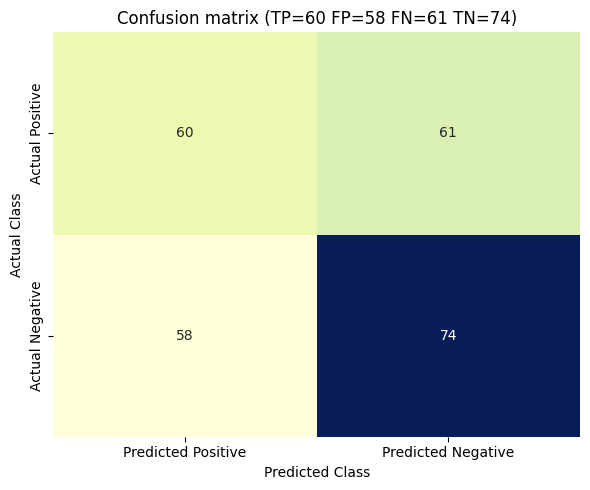

In [305]:
# 2x2 confusion matrix and heatmap
confusion_matrix = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=['Actual Positive', 'Actual Negative'],
    columns=['Predicted Positive', 'Predicted Negative']
)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title(f'Confusion matrix (TP={tp} FP={fp} FN={fn} TN={tn})')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

This further shows the model is roughly at chance for the class balance.

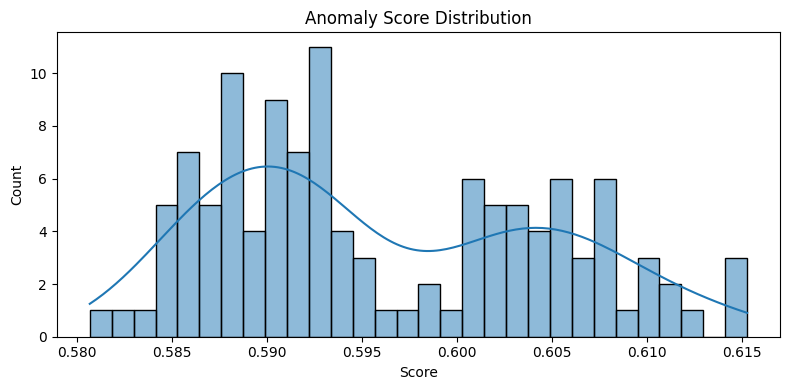

In [308]:
# Anomaly Score Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["anomaly_score"].dropna(), bins=30, kde=True)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

Anomaly_score is tightly clustered around 0.58-0.62, peaking near the best F1 threshold of about 0.586. Small threshold changes will flip many examples. The model's discrimination near the peak is what causes the threshold/PR sensitivity. The few extreme low and high scores make calibration or a secondary signal necessary for separating borderline cases.

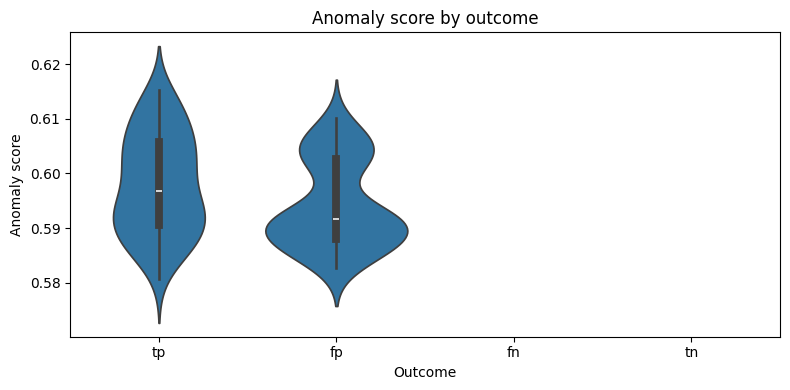

In [309]:
# Violin plot of score by outcome to show separation
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='outcome', y='anomaly_score', inner='box', order=['tp','fp','fn','tn'])
plt.title('Anomaly score by outcome')
plt.xlabel('Outcome')
plt.ylabel('Anomaly score')
plt.tight_layout()
plt.show()

The anomaly scores for true positives and false positives largely overlap, and there is no clear separation between the two around the score mass. Few or no true negatives have anomaly_score values, so the scored data is heavily skewed toward positives. Small threshold changes will flip many examples, making precision/recall volatile.

## Quantify and visualize

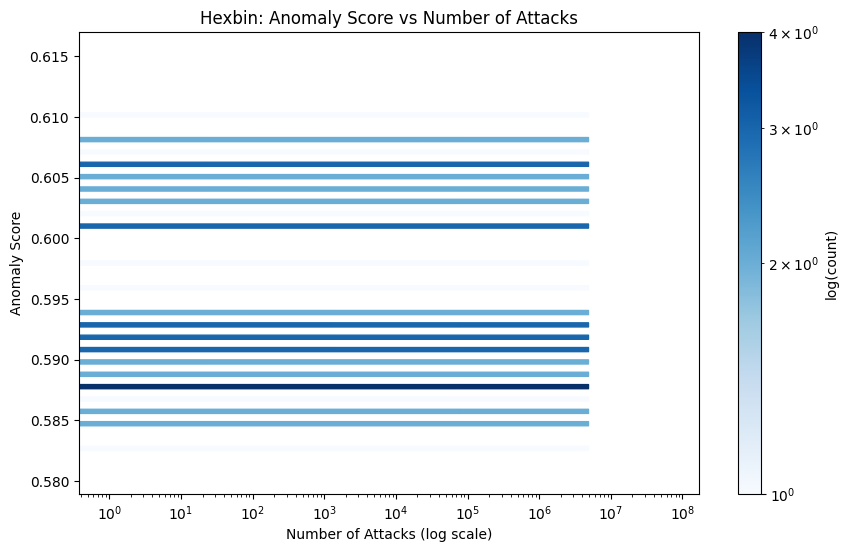

In [312]:
# Log x axis and a hexbin to reveal the density and relationship
plt.figure(figsize=(10,6))
plt.hexbin(df_sample['num_attacks'].replace(0, np.nan).fillna(0.0)+1, df_sample['anomaly_score'], gridsize=60, cmap='Blues', bins='log')
plt.xscale('log')
plt.colorbar(label='log(count)')
plt.xlabel('Number of Attacks (log scale)')
plt.ylabel('Anomaly Score')
plt.title('Hexbin: Anomaly Score vs Number of Attacks')
plt.show()

The density is highest for low-to-moderate attack counts, but there's no clear monotonic trend. Median score changes little across most attack-count bins. Score discrimination is weak for num_attacks alone.

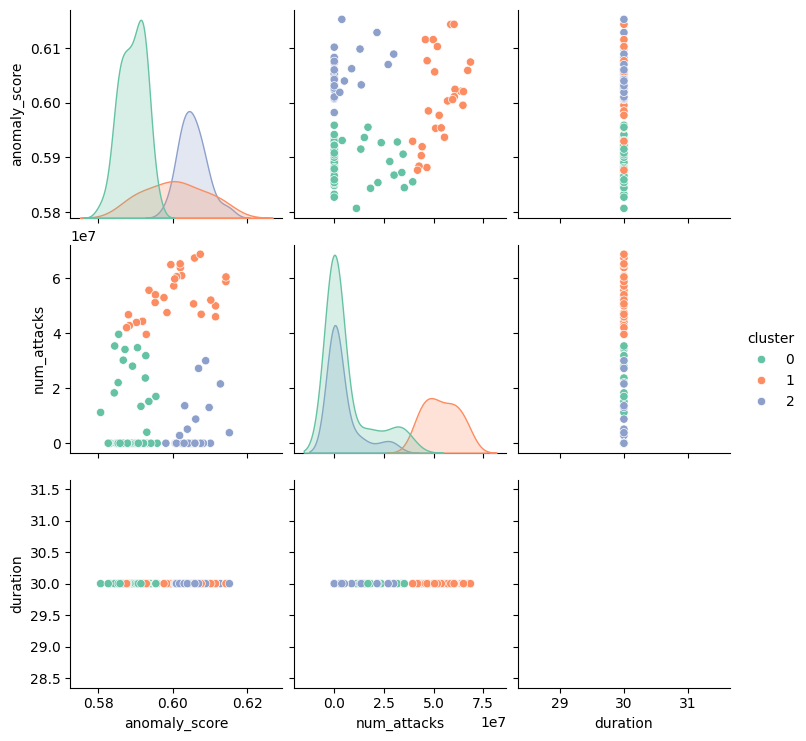

In [325]:
# Pairplot for all features to see how clusters separate across them
sns.pairplot(df_clean, vars=['anomaly_score', 'num_attacks', 'duration'], hue='cluster', palette='Set2')

Clusters separate mainly by scale in num_attacks and duration, while anomaly_score varies within a narrow band across the clusters. Diagonals show distributions, notably that num_attacks and duration are skewed. anomaly_score however is tightly concentrated. There is limited linear separation by anomaly_score, because clustering is driven by magnitude features.

## Diagnose mechanisms

In [328]:
# Trace upstream causes (logs, state transitions, feature values to isolate triggers)
# Filter rows with false positives
fp_df = df[df['is_false_positive'] == 1]

# Calculate the 95th percentile threshold
threshold = df['anomaly_score'].quantile(0.95)
print(f"95th percentile threshold: {threshold}")

# Or high anomaly score
high_anomaly_df = df[df['anomaly_score'] > threshold]

# Group false positives by system
fp_by_system = fp_df['system_id'].value_counts()

# Group high anomaly scores by bucket
high_anomaly_by_bucket = high_anomaly_df['bucket'].value_counts()

# Summary stats for upstream features
print(fp_df[['duration', 'num_attacks', 'anomaly_score']].describe())

95th percentile threshold: 0.6104664944141788
       duration  num_attacks  anomaly_score
count      58.0         58.0      58.000000
mean       30.0          0.0       0.594175
std         0.0          0.0       0.007870
min        30.0          0.0       0.582707
25%        30.0          0.0       0.587967
50%        30.0          0.0       0.591572
75%        30.0          0.0       0.602596
max        30.0          0.0       0.610164


The printed 95th percentile is slightly higher than the observed maximum in the top-58 subset, which was .610164. The subset does not include any rows where anomaly_score is greater than or equal to the computed 95th percentile due to filtering differences, rounding or comparison when selecting the top group. The top group is homogeneous though. This points to a recurring pattern for non-attacks that the model rates relatively highly.

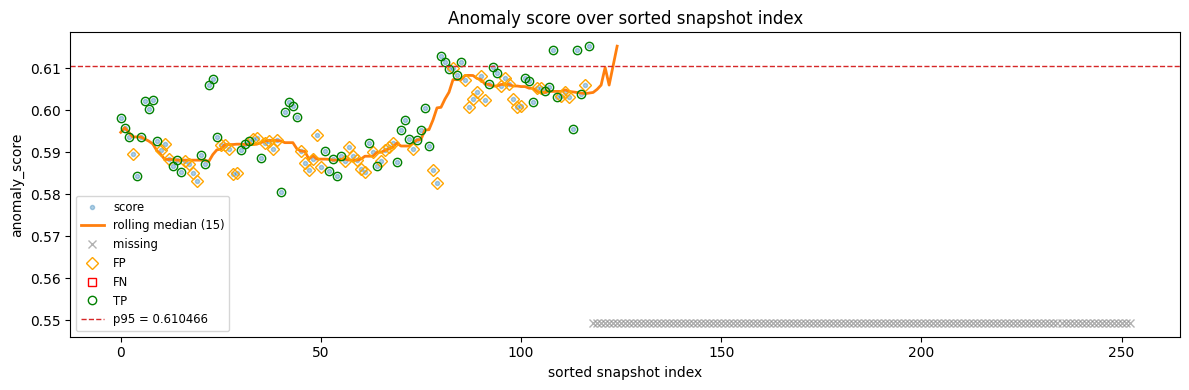

In [334]:
# Sort by snapshot (can also do timestamp)
ts_col = None
for c in ['snapshot_ts','snapshot_time','timestamp','created_at','ts']:
    if c in df.columns:
        ts_col = c
        break

if ts_col:
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    trace_df = df.sort_values(by=ts_col).reset_index(drop=True)
    x = trace_df[ts_col]
    xlabel = ts_col
else:
    # if snapshot_id is not strictly time-ordered, we still use it as an index ordering
    if 'snapshot_id' in df.columns:
        trace_df = df.sort_values(by='snapshot_id').reset_index(drop=True)
    else:
        trace_df = df.reset_index(drop=True)
    x = trace_df.index
    xlabel = 'sorted snapshot index'

# Plot anomaly score with markers for missing / FP / FN and a rolling median
s = trace_df['anomaly_score'].astype(float)
roll = s.rolling(window=15, min_periods=1, center=True).median()

plt.figure(figsize=(12,4))
plt.plot(x, s, '.', alpha=0.35, ms=6, label='score')
plt.plot(x, roll, '-', color='C1', lw=2, label='rolling median (15)')

# mark missing as gray x at 90% of p95 (so they are visible but not on y-axis bottom)
p95 = df['anomaly_score'].dropna().quantile(0.95) if df['anomaly_score'].notna().any() else np.nan
missing_mask = trace_df['anomaly_score'].isna()
if missing_mask.any():
    plt.plot(np.array(x)[missing_mask], np.full(missing_mask.sum(), p95 * 0.9 if not np.isnan(p95) else 0), 'x', color='gray', alpha=0.6, label='missing', ms=6)

# highlight FPs/FNs/TPs
if 'is_false_positive' in trace_df.columns:
    fps = trace_df['is_false_positive']==1
    if fps.any():
        plt.plot(np.array(x)[fps], trace_df.loc[fps,'anomaly_score'], 'D', ms=6, mec='orange', mfc='none', label='FP')
if 'is_false_negative' in trace_df.columns:
    fns = trace_df['is_false_negative']==1
    if fns.any():
        plt.plot(np.array(x)[fns], trace_df.loc[fns,'anomaly_score'], 's', ms=6, mec='red', mfc='none', label='FN')
if 'is_true_positive' in trace_df.columns:
    tps = trace_df['is_true_positive']==1
    if tps.any():
        plt.plot(np.array(x)[tps], trace_df.loc[tps,'anomaly_score'], 'o', ms=6, mec='green', mfc='none', label='TP')

# horizontal p95 line
if not np.isnan(p95):
    plt.axhline(p95, color='C3', ls='--', lw=1, label=f'p95 = {p95:.6f}')

plt.title('Anomaly score over ' + xlabel)
plt.xlabel(xlabel)
plt.ylabel('anomaly_score')
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

FP and TP markers are scattered, so there's no single long run that dominated by FPs or FNs. Some causes are thus systematic and some are isolated instead. Many high-score points are clustered in a small group, so those are the highest-priority windows for upstream tracing.

## Assess signal vs. noise

The borderline anomaly scores cluster tightly, suggesting that borderline cases are algorithmically consistent, but also semantically ambiguous. They hover near the decision threshold due to subtle shifts in features rather than due to a strong signal.

Duration pushes the score up (+0.2438), while num_attacks pushes it down (-0.2438). This produces a near-zero net SHAP contribution, making the row sit in the borderline band. The long duration is seen as evidence of anomalous behavior, but a higher attack count offsets that evidence. The sample is thus ambiguous.

The borderline row with duration = 30 and num_attacks with 51,955,594 is an extreme outlier for num_attacks. The duration is the daset median value of 30. SHAP contributions cancel. The nearby X_test rows show multiple examples with a duration of 30 yet with either 0 or a large number of attacks. This is a systematic data pattern or an instrumentation artifact. It's not a meaningful signal.

In [350]:
# Basic sanity checks
print("num_attacks min, median, max:", df['num_attacks'].min(), df['num_attacks'].median(), df['num_attacks'].max())
print("How many rows have duration == 30:", (df['duration'] == 30).sum())
print("How many rows have extremely large num_attacks:", (df['num_attacks'] > 1e6).sum())

# Inspect distribution tails
print(df['num_attacks'].quantile([0.5, 0.75, 0.90, 0.99]).to_string())

num_attacks min, median, max: 0 0.0 68607990
How many rows have duration == 30: 253
How many rows have extremely large num_attacks: 53
0.50           0.00
0.75       78186.00
0.90    41476063.60
0.99    64959239.36


The distribution of num_attacks is heavy-tailed. The 53 rows are very large, and the 253 rows sharing a duration of 30 show that duration alone carries little variance. We need to transform and robustify the features, so the model doesn't rely on raw extreme counts that simply cancel other signals.

# Summary
## Key Traits
1. anomaly_score is about 0.582-0.610
2. num_attacks is equal to 0
3. duration is equal to 30
4. Many are near the 95th percentile
5. Tight score spread

## Ambiguous Borderline
1. Low num_attacks, anomaly_score clustered near operating threshold
2. Not extreme duration and often around median/IQR boundaries
3. Legitimate low-volume statistical deviations or small feature drift
4. Model sensitivity in threshold region
5. Many borderline FP/FN decisions
6. Create +- 0.001 windows around the threshold and list the FP/FN counts
7. Inspect the recent rolling median around those snapshot indices
8. Mark as borderline tag for human triage and do not auto-escalate unless corroborating signals exist

## High-Count Outliers
1. Large num_attacks and anomaly_score variable often isolated with high counts
2. High-volume events, but occasionally ingest/join errors creating sporatic counts
3. High operational priority but also label risk
4. Inspect raw event logs for snapshot_id and check max_attacks